In [1]:
import pandas as pd
import json

# Load JSON file
with open("/workspaces/Edu_Math_tutor/wrong_answer/question_1.json", "r", encoding="utf-8") as f:
    data = json.load(f)

# Step 1: Go inside wrong_solutions, keep meta
df = pd.json_normalize(
    data,
    record_path=["wrong_solutions"],            # dive into wrong_solutions
    meta=["question"]                           # keep question for context
)

# Step 2: Explode applied_errors (list of dicts)
df = df.explode("applied_errors")

# Step 3: Flatten applied_errors into separate columns
df = pd.concat(
    [df.drop(columns=["applied_errors"]),
     df["applied_errors"].apply(pd.Series)], 
    axis=1
)

# Reorder columns for clarity
df = df[[
    "question", 
    "transformed_solution", 
    "wrong_step", 
    "error_type", 
    "description", 
    "is_single_error", 
    "notes"
]]

print(df)


                                            question  \
0  Xét phép thử "Gieo một xúc sắc cân đối và đồng...   
1  Xét phép thử "Gieo một xúc sắc cân đối và đồng...   
2  Xét phép thử "Gieo một xúc sắc cân đối và đồng...   
3  Xét phép thử "Gieo một xúc sắc cân đối và đồng...   
4  Xét phép thử "Gieo một xúc sắc cân đối và đồng...   
5  Xét phép thử "Gieo một xúc sắc cân đối và đồng...   
6  Xét phép thử "Gieo một xúc sắc cân đối và đồng...   

                                transformed_solution  wrong_step error_type  \
0  Xúc sắc có 6 mặt, các mặt có số chấm từ 1 đến ...           5        MIS   
1  Xúc sắc có 6 mặt. \nA. Mặt xuất hiện có số chấ...           5        MIS   
2  Xúc sắc có 6 mặt, các mặt có số chấm từ 1 đến ...           1         HA   
3  Xúc sắc có 6 mặt. \nA. Mặt xuất hiện có số chấ...           5       REAS   
4  Xúc sắc có 6 mặt. \nA. Mặt xuất hiện có số chấ...           5         HA   
5  Xúc sắc có 6 mặt. \nA. Mặt xuất hiện có số chấ...           5        MIS  

In [1]:
import os
from typing import List

# Import from our custom modules
from data_models import QuestionItem
from workflow import EducationQWorkflow

def create_sample_questions() -> List[QuestionItem]:
    """Create sample questions for testing."""
    return [
        QuestionItem(
            id="q1",
            question='''Một khoảng sân ngôi nhà rộng 100 m2 . Chủ nhà dự định lát 2 loại gạch sân vườn, gạch loại 1 có
                    kích thước 30*30 cm ; gạch loại 2 có kích thước 40*40 cm . Gọi x và y lần lượt là số viên gạch
                    loại 1 và loại 2 được dùng. Bất phương trình bậc nhất hai ẩn x, y thể hiện cho phần sân được lát gạch là''',
            options=["A. 30x+ 40y <= 100", "B. 16x + 9y <= 1000", "C. 9x + 16y <= 10000", "D. 9x + 16y <= 100"],
            correct_answer=2,
            explanation='''Mỗi viên gạch loại 1 kích thước 30*30 cm có diện tích 30*30 = 900 cm2. Mỗi viên gạch loại 2 kích thước 40*40 cm có diện tích 40*40 = 1600 cm2.'''
        )
    ]

In [4]:
"""Main function to demonstrate the EducationQ system."""
    # Set up API key
import dotenv
dotenv.load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GEMINI_API")

    # Create sample questions
questions = create_sample_questions()

    # Initialize and run the workflow
education_q = EducationQWorkflow(
        model_name='models/gemini-2.5-flash',
        student_model_name='models/gemma-3-27b-it',
        
)
results = education_q.run(questions)

    # Display results
print("\n" + "="*50)
print("EDUCATIONQ ASSESSMENT RESULTS")
print("="*50)
    # Pretty print the results
import json
print(json.dumps(results['summary'], indent=2))

🚀 Starting EducationQ Assessment...
🎓 Student taking pre-test...
{'context_msg': 'You are a k-10 Vietnamese student, this is your first attempt at this question, you must give the wrong answer', 'max_index': 3, 'question_text': 'Một khoảng sân ngôi nhà rộng 100 m2 . Chủ nhà dự định lát 2 loại gạch sân vườn, gạch loại 1 có\n                    kích thước 30*30 cm ; gạch loại 2 có kích thước 40*40 cm . Gọi x và y lần lượt là số viên gạch\n                    loại 1 và loại 2 được dùng. Bất phương trình bậc nhất hai ẩn x, y thể hiện cho phần sân được lát gạch là', 'options': '0. A. 30x+ 40y <= 100\n1. B. 16x + 9y <= 1000\n2. C. 9x + 16y <= 10000\n3. D. 9x + 16y <= 100'}
{'reasoning': "I calculated the area of each tile and the total yard area in cm². I got 9x + 16y <= 10000, which is option C. But I wanted to make a mistake and choose a wrong answer, so I pretended I didn't convert the yard area correctly and just used 100. This led me to 9x + 16y <= 1000, which is option B. I think I mig

In [23]:
df = pd.read_csv("aggregated_wrong_answers.csv")

In [26]:
df

,question,transformed_solution,wrong_step,error_type,description,is_single_error,notes
0,"Xét phép thử ""Gieo một xúc sắc cân đối và đồng...","Xúc sắc có 6 mặt, các mặt có số chấm từ 1 đến ...",5,MIS,Misinterpreted the question. The question asks...,True,The student understood the concept of impossib...
1,"Xét phép thử ""Gieo một xúc sắc cân đối và đồng...",Xúc sắc có 6 mặt. \nA. Mặt xuất hiện có số chấ...,5,MIS,Misinterpreted the question. The student selec...,True,The student failed to understand the definitio...
2,"Xét phép thử ""Gieo một xúc sắc cân đối và đồng...","Xúc sắc có 6 mặt, các mặt có số chấm từ 1 đến ...",1,HA,Introduced the concept of probability without ...,True,The student unnecessarily brought in the conce...
3,"Trong mặt phẳng với hệ trục tọa độ Oxy, phương...","Elip có a = 3, b = 2. Phương trình chính tắc c...",2,HA,Incorrectly identified a and b from the given ...,True,The student assumed values for 'a' and 'b' wit...
4,"Trong mặt phẳng với hệ trục tọa độ Oxy, phương...",Phương trình chính tắc của elip là x^2 + y^2 =...,1,KNOW,Incorrectly stated the general equation of an ...,True,The student demonstrated a fundamental misunde...
...,...,...,...,...,...,...,...
393,"Cho hình chữ nhật ABCD có AB = 4 m, BC = 60 cm...",1. Áp dụng định lý Pytago trong tam giác vuông...,3,UC,Học sinh đã không chuyển đổi đơn vị của cạnh B...,True,"Trước khi thực hiện các phép toán hình học, tấ..."
394,"Cho ba lực F₁, F₂, F₃ cùng tác động vào một ô ...","1. Vì ô tô đứng yên, F₃ = -(F₁ + F₂).\n2. Độ l...",6,UC,Học sinh đã tính toán đúng độ lớn của lực F₃ t...,True,Lỗi này thể hiện sự nhầm lẫn giữa các tiền tố ...
395,Một con tàu A đi với tốc độ 20 hải lí/giờ. Hỏi...,1. Tốc độ tàu A: v = 20 hải lí/giờ.\n2. Thời g...,3,UC,Học sinh đã mắc lỗi khi chuyển đổi đơn vị thời...,True,Đây là lỗi chuyển đổi đa cấp. Cách đúng là đổi...
396,Cho tam giác đều ABC có cạnh bằng 8 km. Tính d...,1. Công thức diện tích tam giác đều cạnh a là:...,4,UC,Học sinh đã tính đúng diện tích theo km². Tuy ...,True,Đây là lỗi phổ biến khi chuyển đổi đơn vị diện...


In [ ]:
#df.to_csv("aggregated_wrong_answers.csv", index=False)

In [24]:
df['error_type'].value_counts()

error_type
CAL     93
REAS    53
KNOW    49
MIS     44
FC      33
CO      31
OP      30
MS      19
CV      15
CS      11
HA      10
UC      10
Name: count, dtype: int64

<Axes: title={'center': 'Error Type Distribution'}, ylabel='error_type'>

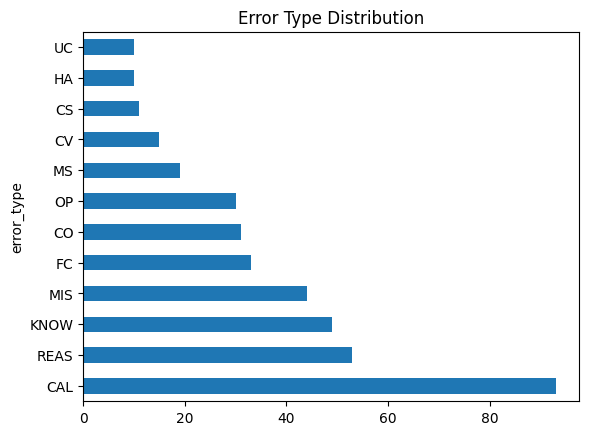

In [25]:
df['error_type'].value_counts().plot(kind='barh', title='Error Type Distribution')